In [ ]:
import sys, os, json
from tqdm import tqdm
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
sys.path.append('../../')


from polygene.model.model import load_trained_model
data_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)
data = sc.concat([sc.read_h5ad(data_path + file) for file in os.listdir(data_path)])
embeddings = np.load('lung_cancer_atlas_embeddings.npy')


In [130]:
import os, sys, json
sys.path.append('../../../')
from tqdm import tqdm
from polygene.eval.metrics import prepare_cell
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=-1)
tokenizer.bypass_inference=True

atlas_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
cells = sc.concat([sc.read_h5ad(atlas_path + file) for file in os.listdir(atlas_path)])
mask = cells.obs['disease'].isin(['lung adenocarcinoma', 'normal']) & cells.obs['cell_type'].isin(['pulmonary alveolar type 2 cell', 'malignant cell'])

cells = cells[mask]
embeddings = np.load('polygene_luca_atlas_embeddings.npy')[mask]
#from tqdm import tqdm
#from polygene.eval.metrics import prepare_cell
#embeddings = []
#for cell in tqdm(cells):
#    cell_dict, labels = prepare_cell(cell, tokenizer)
#    cell_dict['input_ids'][1:1+len(tokenizer.phenotypic_types)] = tokenizer.token_to_id_map[tokenizer.mask_token]
#    output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items()})
#    embeddings.append(output.hidden_states[:, 1+tokenizer.phenotypic_types.index('disease')].detach().cpu().numpy())
#np.save(arr=np.concatenate(embeddings), file="polygene_luca_atlas_embeddings.npy")

from sklearn.decomposition import PCA
pca = PCA(n_components=2, whiten=True, svd_solver="full", random_state=3)
pca_coordinates = pca.fit_transform(embeddings)

loading checkpoint-1500000


In [174]:
cells = cells[:10000]
embeddings = embeddings[:10000]

In [175]:
uicc_stages_numerical = cells.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 3.5}[x]).to_numpy()

In [ ]:
import json
import torch
from polygene.data_utils.tokenization import normalise_str
import torch.nn.functional as F
gene_biotypes = json.load(open("../../data_utils/vocab/gene_biotypes.json"))
ensembl_id_to_gene_name = json.load(open("../../data_utils/vocab/ensembl_to_gene.json"))

def select_protein_encoding_genes(df):
    return df.loc[:, np.array([ensembl_id for ensembl_id in df.columns.tolist() if gene_biotypes.get(ensembl_id, "") == "protein_coding"])]

def gradients(data, phenotype_value):
    # reduction function needs to take alpha (S, D) matrix and return an (S,) vector. 
    reduction_func = lambda m: np.linalg.norm(m, axis=1)
    cell_attributions = []
    for cell in tqdm(data, disable=True):
        x, lbl = prepare_cell(cell, tokenizer)
        x['input_ids'][torch.arange(1, 1+len(tokenizer.phenotypic_types))] = tokenizer.token_to_id_map[tokenizer.mask_token]
        phenotype_value = normalise_str(phenotype_value)
        x['inputs_embeds'] = model.embeddings(x['input_ids'].to(model.device), x['token_type_ids'].to(model.device)).detach().requires_grad_(True)
        y = F.softmax(model(**{k:v.unsqueeze(0).to(model.device) for k,v in x.items() if k != 'str_labels'}).logits, dim=-1) #(B, S, D)
        Ly = y[0, 1+tokenizer.phenotypic_types.index("disease"), tokenizer.flattened_tokens.index(phenotype_value)]
        model.zero_grad()
        Ly.backward()

        attributions_per_gene = reduction_func(x['inputs_embeds'].grad.detach().cpu().numpy()[tokenizer.gene_token_type_offset:])
        gene_ensembl_ids = [list(tokenizer.gene_type_id_map.keys())[gene - tokenizer.gene_token_type_offset] for gene in x['token_type_ids'].detach().cpu().numpy()[tokenizer.gene_token_type_offset:]]
        cell_attributions.append( {k:v for k,v in zip(gene_ensembl_ids, attributions_per_gene)})

    attributions_df = pd.DataFrame(cell_attributions).fillna(0)
    attributions_df = select_protein_encoding_genes(attributions_df)
    attributions_df.columns = pd.Series(attributions_df.columns).apply(lambda ensembl: ensembl_id_to_gene_name[ensembl])
    return attributions_df

import requests

def get_associated_genes(disease_name, disease_ontology_term_id, top=100):
    url = "https://api.platform.opentargets.org/api/v4/graphql"
    disease_ontology_term_id = disease_ontology_term_id.replace(':', '_')

    query_assoc = """
        query associatedTargets($diseaseId: String!, $size: Int!) {
            disease(efoId: $diseaseId) {
                id
                name
                associatedTargets(page: { index: 0, size: $size }) {
                    count
                    rows { target { id approvedSymbol } score }
                }
            }
        }
    """

    variables = {"diseaseId": disease_ontology_term_id, "size": top}
    resp = requests.post(url, json={"query": query_assoc, "variables": variables})
    try:
        response_json = resp.json()
        response = response_json.get('data', {}).get('disease')
    except ValueError:
        return {}
    
    if response is None:
        query_search = """
            query search($term: String!) {
                search(queryString: $term, entityNames: ["disease"]) {
                    hits { id name }
                }
            }
        """
        #search_resp = requests.post(url, json={"query": query_search, "variables": {"term": disease_name}}).json()
        resp = requests.post(url, json={"query": query_search, "variables": {"term": disease_name}})
        try:
            search_resp = resp.json()
        except ValueError:
            return {}
        hits = search_resp.get('data', {}).get('search', {}).get('hits', [])
        if hits:
            new_id = hits[0]['id']
            variables = {"diseaseId": new_id, "size": top}
            response = requests.post(url, json={"query": query_assoc, "variables": variables}).json()['data']['disease']
        else:
            return {}

    if response:
        return {row['target']['approvedSymbol']: row['score'] for row in response['associatedTargets']['rows'][:top]}
    return {}


In [60]:
cells.obs[['cell_type', 'disease']].value_counts(),cells.obs['uicc_stage'].value_counts(), 

(cell_type                       disease                     
 malignant cell                  lung adenocarcinoma             43217
                                 squamous cell lung carcinoma    33234
 pulmonary alveolar type 2 cell  normal                          30508
 epithelial cell of lung         lung adenocarcinoma             19408
 pulmonary alveolar type 2 cell  lung adenocarcinoma             13861
 epithelial cell of lung         normal                           3856
 pulmonary alveolar type 2 cell  squamous cell lung carcinoma     1603
 malignant cell                  normal                           1373
 epithelial cell of lung         squamous cell lung carcinoma     1111
 dtype: int64,
 non-cancer    35737
 I             34890
 III or IV     34256
 IV            20809
 II            15730
 III            6735
 Name: uicc_stage, dtype: int64)

In [ ]:
normal_cell_type_map = {
                        "malignant cell": 'pulmonary alveolar type 2 cell',
                        }
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import combinations
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt, seaborn as sns

dpi=100
fontsize = 14
palette = sns.color_palette('Paired')

W = model.prediction_head[-1].weight
tau = model.temperature
decoder = lambda z: model.prediction_head(z / z.norm()) / model.temperature

from torch.nn.functional import softmax
def riemannian_metric(z, W, tau):
    logits = (W @ z) / tau
    probability_distribution = softmax(logits, dim=0)
    fisher_information_logits = torch.diag(probability_distribution) - probability_distribution[:, None] * probability_distribution[None, :]
    G = (W / tau).T @ fisher_information_logits @ (W / tau)
    return (G + G.T) / 2 + 1e-2 * torch.eye(n=z.shape[0], device=z.device)

def amari_chentsov_tensor(z, W, tau):# skewness tensor
    logits = (W @ z) / tau
    probability_distribution = torch.softmax(logits, dim=0)
    fisher_information_matrix = riemannian_metric(z, W, tau)
    
    mean = (W / tau).T @ probability_distribution
    jacobian = W / tau
    third_moment = torch.einsum('i,ia,ib,ic->abc', probability_distribution, jacobian, jacobian, jacobian)
    mean_covariance = torch.einsum('ab,c->abc', fisher_information_matrix, mean) + torch.einsum('ac,b->abc', fisher_information_matrix, mean) + torch.einsum('bc,a->abc', fisher_information_matrix, mean)
    cubic_mean = torch.einsum('a,b,c->abc', mean, mean, mean)
    return third_moment - mean_covariance - cubic_mean

def levi_civita_connection(z, W, tau):
    G = riemannian_metric(z, W, tau)
    dG = amari_chentsov_tensor(z, W, tau)
    G_inv = torch.inverse(G)
    gamma_ijk = 0.5 * (dG.permute(0, 2, 1) + dG.permute(1, 2, 0) - dG)
    return  0.1 * torch.einsum('kc,abc->abk', G_inv, gamma_ijk)

class Geodesic(nn.Module):
    def __init__(self, z_a, z_b, timepoints, decoder, steps, device="cuda:0", dtype=torch.float32, learning_rate=1e-3, display_tqdm=False):
        super().__init__()
        self.decoder = decoder; self.steps = steps; self.lr = learning_rate; self.display_tqdm = display_tqdm
        z_a = torch.as_tensor(z_a, dtype=dtype, device=device).view(1, -1)
        z_a /= z_a.norm(dim=-1)
        z_b = torch.as_tensor(z_b, dtype=dtype, device=device).view(1, -1)
        z_b /= z_b.norm(dim=-1)
        self.register_buffer("z_a", z_a); self.register_buffer("z_b", z_b)
        t = torch.linspace(0, 1, timepoints, device=device, dtype=dtype)[1:-1].unsqueeze(1)
        self.interior_positions = nn.Parameter(z_a + t * (z_b - z_a))
        self.interior_positions.data = self.interior_positions.data / self.interior_positions.data.norm(dim=-1, keepdim=True)
        self.energy_steps = []

    @property
    def positions(self): return torch.cat([self.z_a, self.interior_positions, self.z_b], dim=0)
    @property
    def optimization_steps(self): return len(self.energy_steps) - 1
    
    def energy(self):
        z = self.positions
        logits = self.decoder(z)
        logp = F.log_softmax(logits[:-1], dim=-1)
        logq = F.log_softmax(logits[1:], dim=-1)
        p = logp.exp()
        kl_divergence = (p * (logp - logq)).sum(dim=-1).sum()
        energy = 2*kl_divergence / (1.0 / (z.shape[0] - 1))

        entropy = -torch.sum(p * logp, dim=-1).mean()
        return  energy + .5*entropy

    def optimize(self, schedule=[10]):
        for n_discretization in schedule:
            self.resample_path(n_discretization)
            opt = torch.optim.SGD([self.interior_positions], lr=self.lr, momentum=0.9)
            pbar = tqdm(range(self.steps), disable=not self.display_tqdm)
            for iteration in pbar:
                opt.zero_grad(set_to_none=True)
                loss = self.energy()
                pbar.set_description(f"Energy: {loss.item():.4f}")
                loss.backward(); opt.step()
                self.energy_steps.append(loss.item())
            with torch.no_grad():
                self.interior_positions.data = self.interior_positions.data / self.interior_positions.data.norm(dim=-1, keepdim=True)
        return self.positions.detach().cpu().numpy()

    @torch.no_grad()
    def resample_path(self, n_discretization):
        z = self.positions
        distances = torch.cat([torch.tensor([0.0], device=z.device), torch.cumsum(torch.norm(z[1:] - z[:-1], dim=-1), dim=0)])
        targets = torch.linspace(0, distances[-1], n_discretization, device=z.device)
        indices = torch.searchsorted(distances, targets, right=True).clamp(1, z.shape[0] - 1)
        low, high = indices - 1, indices
        fractions = (targets - distances[low]) / (distances[high] - distances[low] + 1e-12)
        new_points = torch.lerp(z[low], z[high], fractions.unsqueeze(1))
        new_points /= new_points.norm(dim=-1, keepdim=True)
        self.interior_positions = nn.Parameter(new_points[1:-1].clone())
    
    def discretize(self, manifold, k=1):
        coords = self.positions
        cells = torch.as_tensor(manifold, dtype=coords.dtype, device=coords.device)
        d = torch.cdist(coords, cells)
        t_assign = d.argmin(dim=0)
        mask = torch.zeros_like(d, dtype=torch.bool)
        for t in range(coords.shape[0]):
            idx = torch.where(t_assign == t)[0]
            if idx.numel() > k:
                idx = idx[d[t, idx].topk(k, largest=False).indices]
            mask[t, idx] = True
        return mask.cpu().numpy()
    
    def path_integrated_gradients(self, cells, mask, phenotype_value, disease_ontology_id,
                              disable_pbar=True, k=100):
        """
        cells: anndata (n, g)
        mask: (t, n) generated by discretize function.
        """

        per_step_attributions = []
        per_step_gene_expression = []
        per_step_overlap, per_step_candidate = [], []

        for t in tqdm(range(mask.shape[0]), "IGIG", disable=disable_pbar):
            data = cells[mask[t]]
            attributions = gradients(data, phenotype_value=phenotype_value).sum(axis=0)
            expr = data.to_df()
            expr.columns = [ensembl_id_to_gene_name.get(e, e) for e in expr.columns]
            avg_expr = expr[attributions.index.tolist()].mean(axis=0)

            per_step_attributions.append(attributions)
            per_step_gene_expression.append(avg_expr)

        path_attributions = pd.concat(per_step_attributions, axis=1).T.fillna(0)
        gamma_dot = pd.concat(per_step_gene_expression, axis=1).T.fillna(0).diff().fillna(0)
        cumulative_integrated_gradients = (path_attributions * gamma_dot).cumsum()
        opentarget = get_associated_genes(phenotype_value, disease_ontology_id, k).keys()

        for t in range(cumulative_integrated_gradients.shape[0]):
            ranked = cumulative_integrated_gradients.iloc[t].sort_values(ascending=False)
            topk = ranked.index[:k]
            overlap = [g for g in topk if g in opentarget]
            candidates = [g for g in topk if g not in opentarget]
            per_step_overlap.append(overlap)
            per_step_candidate.append(candidates)

        return dict(
            per_step_overlap=per_step_overlap,
            per_step_candidate=per_step_candidate,
            cumulative_integrated_gradients=cumulative_integrated_gradients.iloc[-1]
        )
    
    def get_amari(self):
        gamma = self.positions
        return [amari_chentsov_tensor(z, W, tau).norm().item() for z in gamma]

healthy_mask = (cells.obs['uicc_stage'] == "I") & (cells.obs['disease'] == "lung adenocarcinoma") & (cells.obs['cell_type'] == 'pulmonary alveolar type 2 cell')
healthy_mask = (cells.obs['uicc_stage'] == "non-cancer") & (cells.obs['disease'] == "normal") & (cells.obs['cell_type'] == 'pulmonary alveolar type 2 cell')
disease_mask = (cells.obs['uicc_stage'] == "II") & (cells.obs['disease'] == "lung adenocarcinoma") & (cells.obs['cell_type'] == 'malignant cell')

from scipy.spatial.distance import cdist
def manifold_projection(path, manifold, closest_k=10):
    # function to project a smooth path onto a manifold or set of discrete observations

    # path is a (t, d) array

    # manifold is a (n,d) array
    distances = cdist(manifold, path) #(t, n) array
    closest_point_indices = np.argsort(distances, axis=-1)[:, :closest_k]
    return closest_point_indices

manifold = embeddings
n_geodesics = 5
n_timepoints = 20
np.random.seed(4)
healthy_indices = np.random.choice(np.arange(healthy_mask.sum()), size=n_geodesics, replace=False)
disease_indices = np.random.choice(np.arange(disease_mask.sum()), size=n_geodesics, replace=False)
igig = []
uicc = []
stats = []
discretizations = []
geodesics = []
print(healthy_indices, disease_indices)

for idx in range(n_geodesics):
    z_a = embeddings[healthy_mask][healthy_indices[idx]]
    z_b = embeddings[disease_mask][disease_indices[idx]]
    geodesic = Geodesic(z_a, z_b, timepoints=n_timepoints, decoder=decoder, steps=1000, learning_rate=1e-3, display_tqdm=True)
    geodesic.optimize([n_timepoints])
    mask = geodesic.discretize(manifold=manifold, k=10)

    igig.append(
                geodesic.path_integrated_gradients(cells, mask, 
                        phenotype_value="lung adenocarcinoma",
                        disease_ontology_id=cells.obs[disease_mask]['disease_ontology_term_id'][0],
                        k=100,
                ))
    stats.append(geodesic.get_amari())
    manifold_indices = manifold_projection(manifold, geodesic.positions.detach().cpu().numpy(), closest_k=100)
    average_uicc_stage = [uicc_stages_numerical[indices].mean() for indices in manifold_indices]
    uicc.append(average_uicc_stage)
    discretizations.append(mask)
    geodesics.append(geodesic.positions.detach().cpu().numpy())
    break

[2414  333 1471  672 3113] [160 598 397   7 357]


Energy: 3.6623:   0%|          | 0/1000 [00:00<?, ?it/s]

Energy: 3.6515: 100%|██████████| 1000/1000 [00:01<00:00, 866.19it/s]


In [ ]:
average_uicc_stage

[0.0, 0.0, 0.1, 0.3, 1.0, 1.0, 1.6, 2.0, 2.0, 2.0]

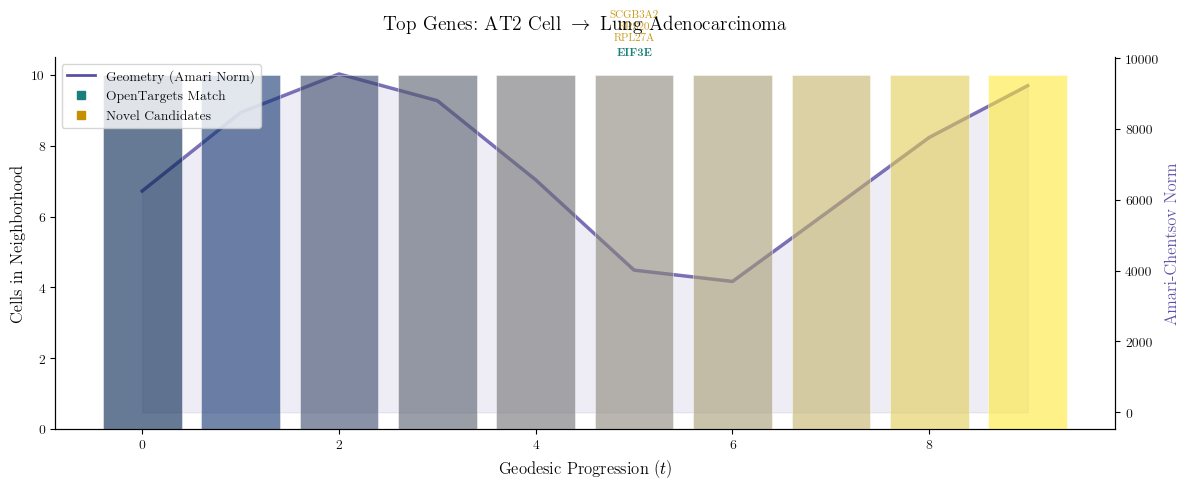

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

def plot_geodesic_gene_emergence_v2(cell_counts, overlap_list, candidate_list, amari_stats, disease_label, cell_type_label, n_genes=3):
    """
    Adapted for the new Geodesic class results.
    """
    time_points = np.arange(len(cell_counts))
    amari_color = "#5B50A5"
    overlap_color = "#1B7F79"
    candidate_color = "#C68F00"
    font_size = 12
    step = 2 # Adjusted step for better readability on n_timepoints=50
    
    # Create normalized colors for bars based on time
    colors = plt.cm.cividis(np.linspace(0, 1, len(time_points)))

    fig, axis = plt.subplots(figsize=(12, 5), dpi=100)
    
    # 1. Bar Chart (Cell Counts)
    axis.bar(time_points, cell_counts, color=colors, width=0.8, alpha=0.6, lw=.5, edgecolor="white")
    axis.set_zorder(1)
    axis.patch.set_alpha(0)

    # 2. Amari-Chentsov Norm (Line Plot)
    axis_stat = axis.twinx()
    axis_stat.set_zorder(0)
    axis_stat.plot(time_points, amari_stats, linewidth=2.5, color=amari_color, alpha=0.8)
    axis_stat.fill_between(time_points, amari_stats, 0, color=amari_color, alpha=0.1)
    axis_stat.set_ylabel("Amari-Chentsov Norm", fontsize=font_size, color=amari_color)
    
    # 3. Gene Annotations
    max_gene_letters = 10
    
    # Helper to calculate text height for stacking
    def get_text_offset(text_str, axis, fig):
        if not text_str: return 0
        t = axis.text(0, 0, text_str, fontsize=font_size-4)
        fig.canvas.draw()
        bbox = t.get_window_extent(renderer=fig.canvas.get_renderer())
        inv = axis.transData.inverted()
        p1 = inv.transform((0, 0))
        p2 = inv.transform((0, bbox.height))
        t.remove()
        return (p2[1] - p1[1]) * 1.5

    for t in range(len(time_points)):
        if t % step != 0 or t == 0: continue
        
        # Format gene names
        ov_genes = [g[:max_gene_letters] for g in overlap_list[t][:n_genes]]
        can_genes = [g[:max_gene_letters] for g in candidate_list[t][:n_genes]]
        
        if not ov_genes and not can_genes: continue
        
        bump = cell_counts.max() * 0.05
        
        # Bottom text: Overlap
        txt_ov = "\n".join(ov_genes)
        axis.text(t, cell_counts[t] + bump, txt_ov, ha='center', va='bottom', 
                  fontsize=font_size-4, color=overlap_color, fontweight='bold')
        
        # Top text: Candidates (Stacked)
        offset = get_text_offset(txt_ov, axis, fig) if ov_genes else 0
        axis.text(t, cell_counts[t] + bump + offset, "\n".join(can_genes), 
                  ha='center', va='bottom', fontsize=font_size-4, color=candidate_color)

    # Styling
    axis.set_xlabel("Geodesic Progression ($t$)", fontsize=font_size)
    axis.set_ylabel("Cells in Neighborhood", fontsize=font_size)
    axis.set_title(f"Top Genes: {cell_type_label} $\\rightarrow$ {disease_label}", fontsize=font_size + 2, pad=20)
    
    # Legend
    handles = [
        Line2D([0], [0], color=amari_color, lw=2, label='Geometry (Amari Norm)'),
        Line2D([0], [0], color=overlap_color, lw=0, marker='s', label='OpenTargets Match'),
        Line2D([0], [0], color=candidate_color, lw=0, marker='s', label='Novel Candidates')
    ]
    axis.legend(handles=handles, loc='upper left', fontsize=font_size-2, frameon=True)

    # Clean Spines
    for ax in [axis, axis_stat]:
        ax.spines['top'].set_visible(False)
        ax.tick_params(labelsize=font_size-2)
    
    plt.tight_layout()
    plt.show()

# --- DATA PREPARATION FOR THE PLOT ---

# 1. Aggregate results from the igig list (Integrated Gradients)
# Since you ran break after the first geodesic, we take index 0
g_idx = 0 
overlap_genes = igig[g_idx]['per_step_overlap']
candidate_genes = igig[g_idx]['per_step_candidate']
amari_vals = stats[g_idx]

# 2. Calculate cell counts from discretization mask
# mask shape is (timepoints, cells)
current_mask = discretizations[g_idx]
cell_counts = current_mask.sum(axis=1)

# 3. Define Labels
disease_label = "Lung Adenocarcinoma"
cell_type_label = "AT2 Cell"

# Execute
plot_geodesic_gene_emergence_v2(
    cell_counts, 
    overlap_genes, 
    candidate_genes, 
    amari_vals, 
    disease_label, 
    cell_type_label
)

In [151]:
candidate_genes[10]

['SFTPC',
 'SFTPA2',
 'SFTPA1',
 'SCGB3A1',
 'AGER',
 'KRT13',
 'GOLGB1',
 'SFTPB',
 'GSTM1',
 'NAPSA',
 'TNNC1',
 'TNFSF13',
 'MRPL53',
 'ABCA3',
 'MUC5AC',
 'EIF5B',
 'RPL23',
 'GOLGA4',
 'HSPA6',
 'IFITM1',
 'H3-3A',
 'TFF1',
 'GABARAP',
 'GADD45B',
 'CLDN18',
 'GGTLC1',
 'NDUFA11',
 'TOP1',
 'MUCL3',
 'ABCF1',
 'PRSS1',
 'MATR3_ENSG00000015479',
 'EIF3J',
 'SCGB3A2',
 'GKN2',
 'ZRSR2',
 'RPL27A',
 'RNASEK',
 'CSNK2B',
 'CKB',
 'PSMA2',
 'TTN',
 'EMP2',
 'RPS10',
 'HAUS7',
 'RPL17',
 'ERCC5',
 'SLTM',
 'IRF9',
 'GLRX5',
 'WFDC2',
 'REG4',
 'FKBP5',
 'SMC4',
 'SUSD2',
 'ECH1',
 'TMC5',
 'ARF5',
 'ATP1A1',
 'ARID4A',
 'CACNA2D2',
 'ECI1',
 'FDX2',
 'HOPX',
 'HAUS4',
 'CEBPD',
 'FOSB',
 'TPT1',
 'AKAP9',
 'PRPF4B',
 'S100A2',
 'BCKDHA',
 'AQP4',
 'LPCAT1',
 'MUC13',
 'SON',
 'CTSH',
 'CHD2',
 'PSMB10',
 'SMARCA5',
 'TRIB1',
 'AREG',
 'NOP56',
 'SREK1',
 'PUM3',
 'RPS24',
 'TAF10',
 'METTL7A',
 'CEACAM5',
 'PSMB7',
 'S100P',
 'DHX36',
 'TMBIM4',
 'MLPH',
 'SULT1A3',
 'TCN1',
 'EIF5']

In [169]:
np.linspace(0, 1, num=len(amari_vals))

array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ])

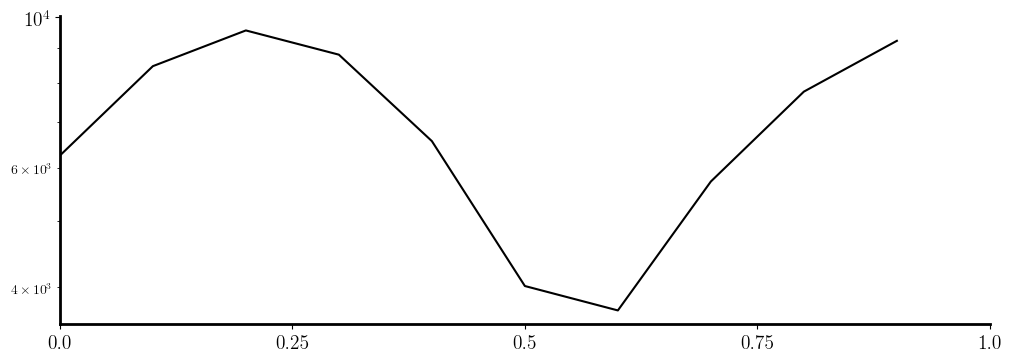

0

In [184]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

def geodesic_genes(overlap_list, candidate_list, amari_stats, disease_label, cell_type_label, n_genes=3):
    font_size = 14
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 4), dpi=100)
    ax.plot(np.arange(len(amari_stats)), amari_stats, color="k")
    #ax.plot(np.arange(len(amari_stats)), uicc[0], color="blue")
    ax.spines[['bottom', 'left']].set_linewidth(2)
    ax.spines[['top', 'right']].set_linewidth(0)
    ax.set_xlim(0, len(amari_stats))
    ax.set_yscale("log")
    ax.tick_params("both", labelsize=fontsize)
    ax.set_xticks(np.linspace(0, len(amari_stats), num=5), np.linspace(0, 1, num=5))
    plt.show()
    return 0
    # 2. Amari-Chentsov Norm (Line Plot)
    axis_stat = axis.twinx()
    axis_stat.set_zorder(0)
    axis_stat.plot(time_points, amari_stats, linewidth=2.5, color=amari_color, alpha=0.8)
    axis_stat.fill_between(time_points, amari_stats, 0, color=amari_color, alpha=0.1)
    axis_stat.set_ylabel("Amari-Chentsov Norm", fontsize=font_size, color=amari_color)
    
    # 3. Gene Annotations
    max_gene_letters = 10
    
    # Helper to calculate text height for stacking
    def get_text_offset(text_str, axis, fig):
        if not text_str: return 0
        t = axis.text(0, 0, text_str, fontsize=font_size-4)
        fig.canvas.draw()
        bbox = t.get_window_extent(renderer=fig.canvas.get_renderer())
        inv = axis.transData.inverted()
        p1 = inv.transform((0, 0))
        p2 = inv.transform((0, bbox.height))
        t.remove()
        return (p2[1] - p1[1]) * 1.5

    for t in range(len(time_points)):
        if t % step != 0 or t == 0: continue
        
        # Format gene names
        ov_genes = [g[:max_gene_letters] for g in overlap_list[t][:n_genes]]
        can_genes = [g[:max_gene_letters] for g in candidate_list[t][:n_genes]]
        
        if not ov_genes and not can_genes: continue
        
        bump = cell_counts.max() * 0.05
        
        # Bottom text: Overlap
        txt_ov = "\n".join(ov_genes)
        axis.text(t, cell_counts[t] + bump, txt_ov, ha='center', va='bottom', 
                  fontsize=font_size-4, color=overlap_color, fontweight='bold')
        
        # Top text: Candidates (Stacked)
        offset = get_text_offset(txt_ov, axis, fig) if ov_genes else 0
        axis.text(t, cell_counts[t] + bump + offset, "\n".join(can_genes), 
                  ha='center', va='bottom', fontsize=font_size-4, color=candidate_color)

    # Styling
    axis.set_xlabel("Geodesic Progression ($t$)", fontsize=font_size)
    axis.set_ylabel("Cells in Neighborhood", fontsize=font_size)
    axis.set_title(f"Top Genes: {cell_type_label} $\\rightarrow$ {disease_label}", fontsize=font_size + 2, pad=20)
    
    # Legend
    handles = [
        Line2D([0], [0], color=amari_color, lw=2, label='Geometry (Amari Norm)'),
        Line2D([0], [0], color=overlap_color, lw=0, marker='s', label='OpenTargets Match'),
        Line2D([0], [0], color=candidate_color, lw=0, marker='s', label='Novel Candidates')
    ]
    axis.legend(handles=handles, loc='upper left', fontsize=font_size-2, frameon=True)

    # Clean Spines
    for ax in [axis, axis_stat]:
        ax.spines['top'].set_visible(False)
        ax.tick_params(labelsize=font_size-2)
    
    plt.tight_layout()
    plt.show()

# --- DATA PREPARATION FOR THE PLOT ---

# 1. Aggregate results from the igig list (Integrated Gradients)
# Since you ran break after the first geodesic, we take index 0
g_idx = 0 
overlap_genes = igig[g_idx]['per_step_overlap']
candidate_genes = igig[g_idx]['per_step_candidate']
amari_vals = stats[g_idx]

# 2. Calculate cell counts from discretization mask
# mask shape is (timepoints, cells)
current_mask = discretizations[g_idx]
cell_counts = current_mask.sum(axis=1)

geodesic_genes(
    overlap_genes, 
    candidate_genes, 
    amari_vals, 
    disease_label, 
    cell_type_label
)